In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.ensemble import RandomForestClassifier

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

# 精度評価
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyClassifier 
import lightgbm as lgb
import optuna

In [15]:
train = pd.read_csv('../../data/processed/train_age_flags.csv')
test = pd.read_csv('../../data/processed/test_age_flags.csv')

In [16]:
# 説明変数と目的変数に分割

# 説明変数
X = train.drop(['Exited'],axis=1)
# 目的変数
y = train['Exited']

In [17]:
# データの分割
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=y)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (11250, 23), X_test: (3750, 23)


## 複数のモデルでROCを比較

In [18]:
clf = LazyClassifier(ignore_warnings=True, predictions=True)   #設定
models, predictions = clf.fit(X_train, X_test, y_train, y_test) #実行

In [19]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.845067,0.839488,0.915799,0.854099,0.876438,0.845067,0.102636
BernoulliNB,0.865867,0.832624,0.914216,0.870393,0.878660,0.865867,0.111976
LGBMClassifier,0.897600,0.821447,0.930375,0.895278,0.894322,0.897600,0.354772
LogisticRegression,0.899733,0.821329,0.929876,0.897053,0.896257,0.899733,0.116756
AdaBoostClassifier,0.900000,0.821010,0.929562,0.897239,0.896483,0.900000,0.969856
CalibratedClassifierCV,0.899733,0.819871,0.929927,0.896876,0.896147,0.899733,0.326326
LinearDiscriminantAnalysis,0.894933,0.819772,0.927638,0.892848,0.891812,0.894933,0.118714
Perceptron,0.857867,0.818849,0.905747,0.862510,0.870561,0.857867,0.105379
LinearSVC,0.900000,0.818094,0.929898,0.896881,0.896290,0.900000,0.124714


## LightGBMを用いてモデルを作成する

In [20]:
dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test)

params = {
    'objective': 'binary',
    'metrics': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.01   
}

model = lgb.train(params, dtrain, num_boost_round=1000)
pred_prob = model.predict(X_test)

## Optunaを用いてhyper parameterのチューニングを行う

In [21]:
# 目的関数の定義
def objective(trial):
    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_test, y_test)

    params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'lambda_l1'         : trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2'         : trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),

        'force_col_wise':True,
        'random_state': 0,
    }

    model = lgb.train(
        params=params,
        train_set=dtrain,
        num_boost_round=100,
    )

    pred = model.predict(X_test, num_iteration=model.best_iteration)
    score = roc_auc_score(y_test, pred)
    
    return score

In [22]:
# 最適化の実行
optuna.logging.disable_default_handler()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), )
study.optimize(objective, n_trials=60)

In [23]:
# 最も精度の高いパラメータ
print('＝＝＝＝ベストパラメーター＝＝＝＝＝')
print(study.best_params)

# 最も精度の高いパラメータで学習を再度実行
best_params = {
        'objective': 'binary',
        'metrics': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1
    }
best_params.update(study.best_params)

＝＝＝＝ベストパラメーター＝＝＝＝＝
{'lambda_l1': 9.362141539227213, 'lambda_l2': 0.026142139625714874, 'learning_rate': 0.08712891584082527, 'num_leaves': 231, 'feature_fraction': 0.5572403483611141, 'bagging_fraction': 0.8508404135887832, 'bagging_freq': 3, 'min_child_samples': 48}


## 層化K分割を用いてクロスバリデーションを行い、モデルの性能を評価する

In [24]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)
valid_score = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[train_index], X.iloc[valid_index]
    y_tr, y_va = y.iloc[train_index], y.iloc[valid_index]
    set_tr = lgb.Dataset(X_tr, y_tr)
    
    model_tmp = lgb.train(
        params = best_params,
        train_set = set_tr
    )

    pred = model_tmp.predict(X_va)
    roc_score = roc_auc_score(y_va, pred)
    valid_score.append(roc_score)

    print(f'fold:{fold + 1} roc_score: {roc_score}')

cv_score = np.mean(valid_score)
print(f'cv_score: {cv_score}')

fold:1 roc_score: 0.9347760042040267
fold:2 roc_score: 0.9371031355032242
fold:3 roc_score: 0.9367829069092741
fold:4 roc_score: 0.9332747616076024
fold:5 roc_score: 0.9318152582082526
cv_score: 0.934750413286476


In [25]:
best_model = lgb.train(
    params = best_params,
    train_set = dtrain
)

pd.DataFrame(best_model.feature_importance(), index=X_train.columns )

,0
CreditScore,278
Age,302
Tenure,163
Balance,268
EstimatedSalary,299
is_young_stable,16
is_active_churn,12
is_peak_churn,38
is_senior_retire,0
Geography_France,20


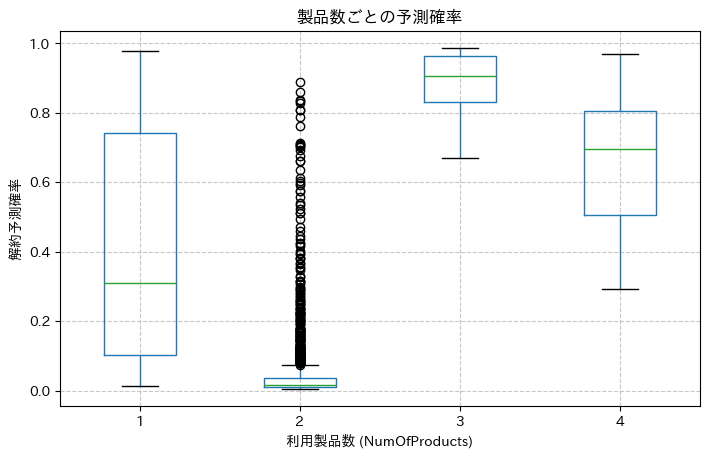

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. テストデータに対する予測確率を取得
y_test_proba = best_model.predict(X_test)

# 2. X_testのコピーを作成し、予測確率を追加
X_test_check = X_test.copy()
X_test_check['pred_proba'] = y_test_proba

# --------------------------------------------------
# 【修正】'2.0' のような小数点文字列を安全に整数に変換する
# --------------------------------------------------
# 列名に 'NumOfProducts_' が含まれる列（ダミー変数）を自動で全取得
products_columns = [col for col in X_test_check.columns if 'NumOfProducts_' in str(col)]

# 1が入っている列名を探し、数値を復元
X_test_check['NumOfProducts'] = (
    X_test_check[products_columns]
    .idxmax(axis=1)
    .astype(str)
    .str.replace('NumOfProducts_', '')
    .astype(float)  # 【重要】先に '2.0' を 2.0 (float型) に変換
    .astype(int)    # そのあと 2.0 を 2 (int型) に変換
)
# --------------------------------------------------

# 3. 製品数ごとの予測確率の分布を描画
X_test_check.boxplot(column='pred_proba', by='NumOfProducts', figsize=(8, 5))
plt.title('製品数ごとの予測確率')
plt.xlabel('利用製品数 (NumOfProducts)')
plt.ylabel('解約予測確率')
plt.suptitle('') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 学習済みモデルを用いてテストデータを予測

In [39]:
# 1. 欠損値を埋める
test_encoded = test.fillna(0)

# 2. 提出用の「確率」を予測する (predict ではなく predict_proba)
# ※学習時と同じ列にするため、もし 'id' や 'Exited' が残っていれば drop してください
X_test_final = test_encoded.drop(columns=['id', 'Exited'], errors='ignore')
pred_proba = best_model.predict(X_test_final)

In [29]:
np.savetxt('../../model/pred_test_proba.txt', pred_proba)

print("予測確率の保存が完了しました。左のフォルダから 'pred_test_proba.txt' をダウンロードするか、次のファイルで読み込んでください。")

予測確率の保存が完了しました。左のフォルダから 'pred_test_proba.txt' をダウンロードするか、次のファイルで読み込んでください。
